# Urbano, Antonio Gabriel L.
# 2ECE-A

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

In [21]:
df = pd.read_excel('board2.xlsx')

df.columns = df.columns.str.strip()

df['Average'] = df[
    ['Math', 'Electronics', 'GEAS', 'Communication']
].mean(axis=1)

display(df.head())

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication,Average
0,S1,Male,Instrumentation,Luzon,58,89,75,78,75.00
1,S2,Female,Communication,Mindanao,52,75,90,52,67.25
2,S3,Female,Instrumentation,Mindanao,83,74,77,57,72.75
3,S4,Male,Instrumentation,Visayas,65,58,91,68,70.50
4,S5,Male,Communication,Luzon,59,86,43,88,69.00


### A. VISAYAS COMMUNICATION DATAFRAME

In [22]:
vis_comm_filter = (df['Hometown'] == 'Visayas') & (
    df['Track'] == 'Communication'
)
VisComm = df[vis_comm_filter][
    ['Name', 'Gender', 'Math', 'Electronics', 'Average']
]

display(VisComm)
print(f"Number of rows in VisComm: {len(VisComm)}")

,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,54.75
11,S12,Male,89,67,76.00
17,S18,Male,81,40,63.50
21,S22,Female,64,39,62.50
27,S28,Male,85,53,67.75


Number of rows in VisComm: 5


### B. VISAYAS FEMALE DATAFRAME

In [23]:
vis_female_filter = (df['Hometown'] == 'Visayas') & (df['Gender'] == 'Female')
VisFemale = df[vis_female_filter][
    ['Name', 'Track', 'GEAS', 'Electronics', 'Average']
]

print("--- VisFemale DataFrame ---")
display(VisFemale)

print("\n--- VisFemale with Average >= 60 ---")
display(VisFemale[VisFemale['Average'] >= 60])

--- VisFemale DataFrame ---


,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
10,S11,Communication,48,56,54.75
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
23,S24,Microelectronics,60,45,57.75
25,S26,Instrumentation,83,47,65.75



--- VisFemale with Average >= 60 ---


,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
25,S26,Instrumentation,83,47,65.75


### C. CATEGORY-AVERAGE VISUALIZATION

####  Part a and b

In [24]:
track_mean = df.groupby('Track')['Average'].mean().reset_index()
gender_mean = df.groupby('Gender')['Average'].mean().reset_index()
hometown_mean = df.groupby('Hometown')['Average'].mean().reset_index()

print("Mean Average by Track:")
display(track_mean)

print("\nMean Average by Gender:")
display(gender_mean)

print("\nMean Average by Hometown:")
display(hometown_mean)

Mean Average by Track:


,Track,Average
0,Communication,67.975
1,Instrumentation,65.225
2,Microelectronics,67.500



Mean Average by Gender:


,Gender,Average
0,Female,66.616667
1,Male,67.183333



Mean Average by Hometown:


,Hometown,Average
0,Luzon,68.083333
1,Mindanao,66.678571
2,Visayas,65.750000


####  Part c

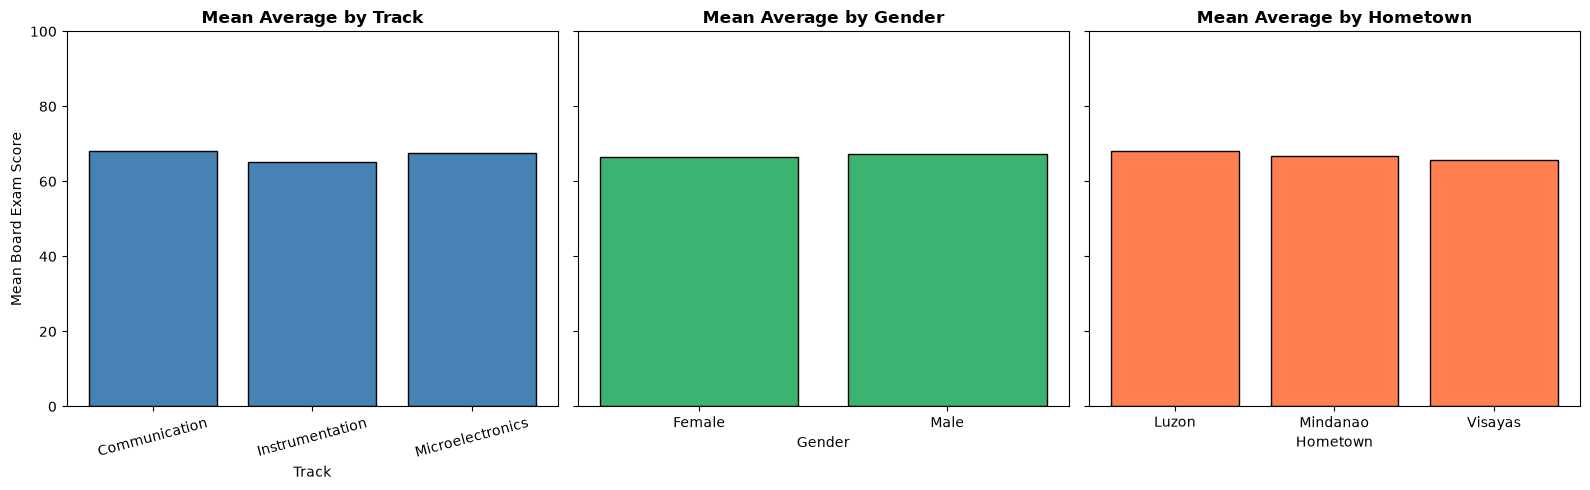

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

# Plot 1: Track
axes[0].bar(
    track_mean['Track'],
    track_mean['Average'],
    color='steelblue',
    edgecolor='black',
)
axes[0].set_title('Mean Average by Track', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Track', fontsize=10)
axes[0].set_ylabel('Mean Board Exam Score', fontsize=10)
axes[0].tick_params(axis='x', rotation=15)

# Plot 2: Gender
axes[1].bar(
    gender_mean['Gender'],
    gender_mean['Average'],
    color='mediumseagreen',
    edgecolor='black',
)
axes[1].set_title('Mean Average by Gender', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Gender', fontsize=10)

# Plot 3: Hometown
axes[2].bar(
    hometown_mean['Hometown'],
    hometown_mean['Average'],
    color='coral',
    edgecolor='black',
)
axes[2].set_title('Mean Average by Hometown', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Hometown', fontsize=10)

# Set consistent scale appropriate to score percentages
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

####  Part d

In [26]:
top_track = track_mean.loc[track_mean['Average'].idxmax()]
top_gender = gender_mean.loc[gender_mean['Average'].idxmax()]
top_hometown = hometown_mean.loc[hometown_mean['Average'].idxmax()]

print(
    f"1. Track: The category with the highest sample mean average is "
    f"'{top_track['Track']}' with a mean score of {top_track['Average']:.2f}."
)
print(
    f"2. Gender: The category with the highest sample mean average is "
    f"'{top_gender['Gender']}' with a mean score of {top_gender['Average']:.2f}."
)
print(
    f"3. Hometown: The category with the highest sample mean average is "
    f"'{top_hometown['Hometown']}' with a mean score of {top_hometown['Average']:.2f}."
)

1. Track: The category with the highest sample mean average is 'Communication' with a mean score of 67.97.
2. Gender: The category with the highest sample mean average is 'Male' with a mean score of 67.18.
3. Hometown: The category with the highest sample mean average is 'Luzon' with a mean score of 68.08.
